<a href="https://colab.research.google.com/github/vencov/FAV_upsidedown/blob/main/NoiseSignals/EX_noise_spl_spectral_density.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Noise, Sound Pressure Level, and Spectral Density

This notebook is a hands-on tour of three quantities that get mixed up constantly when
talking about noise signals:

1. **Sound pressure level (SPL)** – a single dB number describing the *overall* loudness
   of a signal, based on its RMS value.
2. **Spectral (density) level** – how that "loudness" is *distributed* across frequency,
   in dB **per Hz**.
3. **Band level** – the SPL you'd measure if you only looked at a limited frequency band
   $\Delta f$, related to the spectral density level by

$$
L = l + 10\log_{10}\!\left(\frac{\Delta f}{\mathrm{Hz}}\right)
$$

We'll generate random (Gaussian white) noise, set its level in dB SPL, look at it in the
time domain, move to the frequency domain, and then band-limit it to see the formula
above in action — interactively.

**Workflow**
- Part 1 — Generate noise, set its dB SPL, verify from the RMS.
- Part 2 — Move to the spectral domain: power spectral density (PSD) and spectral density level.
- Part 3 — The level ↔ bandwidth relationship, $L = l + 10\log_{10}(\Delta f/\mathrm{Hz})$.
- Part 4 — Interactive explorer: SPL slider + optional bandpass filter.



## 0. Setup

We work in **pressure units (Pa)**, because that's what "dB SPL" is defined against:

$$
L_p = 20\log_{10}\!\left(\frac{p_{\text{rms}}}{p_0}\right), \qquad p_0 = 20\ \mu\text{Pa}
$$

$p_0 = 20\,\mu\text{Pa}$ is the standard reference sound pressure in air (roughly the
threshold of human hearing at 1 kHz). Everything below is built around this reference.


In [1]:

import numpy as np
import scipy.signal as sig
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interactive_output, FloatSlider, FloatLogSlider, Checkbox, VBox, HBox
from IPython.display import display, Markdown

plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['axes.grid'] = True

# Reference sound pressure, 20 micropascal (standard reference for dB SPL in air)
P0 = 20e-6  # Pa

def spl_to_rms(spl_db, p0=P0):
    '''Target dB SPL -> required RMS pressure in Pa.'''
    return p0 * 10.0**(spl_db / 20.0)

def rms_to_spl(p_rms, p0=P0):
    '''RMS pressure in Pa -> dB SPL.'''
    p_rms = np.maximum(np.asarray(p_rms), 1e-30)
    return 20.0 * np.log10(p_rms / p0)

print("P0 (reference pressure) =", P0, "Pa  (0 dB SPL)")


P0 (reference pressure) = 2e-05 Pa  (0 dB SPL)



## Part 1 — Generate noise and set its level in dB SPL

We generate Gaussian white noise $x[n]$, then rescale it so that its **RMS value in
the time domain** equals the pressure that corresponds to the dB SPL you choose:

$$
p_{\text{rms}} = p_0 \cdot 10^{L_p/20}
$$

This is exactly what "setting the level in dB SPL" means for a noise signal — SPL is a
statement about the RMS of the time-domain waveform, nothing more.


Target SPL   : 60.00 dB
Measured SPL : 60.00 dB   (from RMS of the time-domain signal)


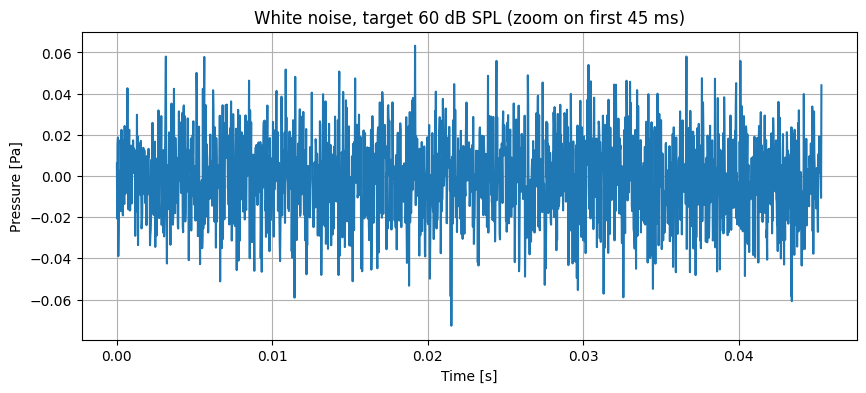

In [2]:

def generate_white_noise(fs, duration, spl_db, seed=None):
    '''Generate Gaussian white noise, scaled so its time-domain RMS matches spl_db.'''
    rng = np.random.default_rng(seed)
    n = int(round(fs * duration))
    x = rng.standard_normal(n)
    x = x - x.mean()
    target_rms = spl_to_rms(spl_db)
    x = x / np.std(x) * target_rms   # Pa
    t = np.arange(n) / fs
    return t, x

# --- Demo: 60 dB SPL white noise ---
fs = 44100        # Hz, sample rate
duration = 1.0    # s
target_spl = 60.0 # dB SPL

t, x = generate_white_noise(fs, duration, target_spl, seed=42)
measured_spl = rms_to_spl(np.sqrt(np.mean(x**2)))

print(f"Target SPL   : {target_spl:.2f} dB")
print(f"Measured SPL : {measured_spl:.2f} dB   (from RMS of the time-domain signal)")

plt.plot(t[:2000], x[:2000])
plt.xlabel("Time [s]"); plt.ylabel("Pressure [Pa]")
plt.title(f"White noise, target {target_spl:.0f} dB SPL (zoom on first {2000/fs*1000:.0f} ms)")
plt.show()



## Part 2 — Into the spectral domain: PSD and spectral density level

A single SPL number tells you nothing about *how* the energy is spread over frequency.
For that we need the **power spectral density (PSD)**, $G_{xx}(f)$, in Pa²/Hz — estimated
here with Welch's method (averaged, windowed periodograms; much less noisy than a raw FFT).

From the PSD we define the **spectral density level**

$$
l(f) = 10\log_{10}\!\left(\frac{G_{xx}(f)}{p_0^2}\right) \quad \left[\text{dB re } (20\,\mu\text{Pa})^2/\text{Hz}\right]
$$

This is a *density* — "how many dB per Hz" — which is why it's sometimes called dB/Hz.
For **white** noise this quantity is (statistically) flat with frequency: equal power in
every Hz-wide slice of the spectrum.


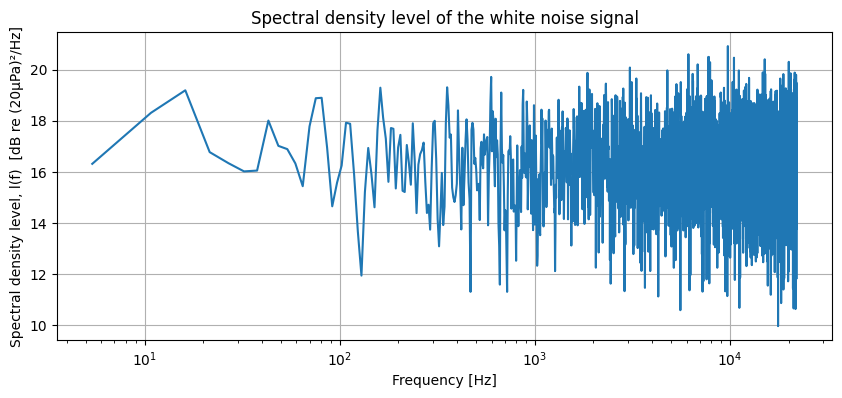

Mean spectral density level over the whole band: 16.30 dB/Hz


In [3]:

def compute_psd(x, fs, nperseg=4096):
    '''Welch PSD estimate, in Pa^2/Hz.'''
    f, Pxx = sig.welch(x, fs=fs, window='hann', nperseg=nperseg, scaling='density')
    return f, Pxx

def psd_to_density_level(Pxx, p0=P0):
    '''PSD [Pa^2/Hz] -> spectral density level l(f) [dB/Hz].'''
    Pxx = np.maximum(np.asarray(Pxx), 1e-30)
    return 10.0 * np.log10(Pxx / p0**2)

f, Pxx = compute_psd(x, fs, nperseg=8192)
l_f = psd_to_density_level(Pxx)

plt.semilogx(f[1:], l_f[1:])
plt.xlabel("Frequency [Hz]")
plt.ylabel("Spectral density level, l(f)  [dB re (20µPa)²/Hz]")
plt.title("Spectral density level of the white noise signal")
plt.show()

print(f"Mean spectral density level over the whole band: {np.mean(l_f[1:]):.2f} dB/Hz")



## Part 3 — Relating band level to spectral density level

If the spectrum is flat (density level $\approx l$, constant) over a bandwidth
$\Delta f$, then the **total level you'd measure over that band** is the density level
"stacked up" over all the Hz-wide slices it contains:

$$
L = l + 10\log_{10}\!\left(\frac{\Delta f}{\mathrm{Hz}}\right)
$$

Two useful ways to read this:
- For **fixed density level** $l$, a *wider* band always measures *louder* ($L$ grows
  with $\Delta f$) — even though nothing changed "per Hz".
- Conversely, if you know the *total* level $L$ measured over a *known* bandwidth
  $\Delta f$, you can back out the density level: $l = L - 10\log_{10}(\Delta f/\mathrm{Hz})$.

Let's check this against our own signal: measure the RMS SPL over the full analysis
band (0 Hz to Nyquist, $\Delta f = f_s/2$), and compare it with $l + 10\log_{10}(\Delta f)$
computed from the PSD.


In [4]:

delta_f_full = fs / 2.0                  # Nyquist bandwidth = the whole band we generated
l0 = np.mean(l_f[1:])                    # mean spectral density level (skip f=0 bin)
L_predicted = l0 + 10 * np.log10(delta_f_full)
L_measured  = rms_to_spl(np.sqrt(np.mean(x**2)))

print(f"Mean spectral density level, l          : {l0:.2f} dB/Hz")
print(f"Bandwidth, Δf                           : {delta_f_full:.1f} Hz")
print(f"Predicted  L = l + 10·log10(Δf/Hz)      : {L_predicted:.2f} dB")
print(f"Measured   L (directly from time-domain RMS): {L_measured:.2f} dB")
print()
print("These two should agree closely (small differences come from PSD estimation noise).")


Mean spectral density level, l          : 16.30 dB/Hz
Bandwidth, Δf                           : 22050.0 Hz
Predicted  L = l + 10·log10(Δf/Hz)      : 59.74 dB
Measured   L (directly from time-domain RMS): 60.00 dB

These two should agree closely (small differences come from PSD estimation noise).



## Part 4 — Band-limiting the noise: filtering in the frequency domain

Now let's make $\Delta f$ something we control directly, by **bandpass filtering** the
noise to a chosen range $[f_{lo}, f_{hi}]$ (a Butterworth filter applied with
zero phase distortion via `sosfiltfilt`). After filtering we rescale the signal so its
RMS matches whatever dB SPL you asked for — this is now the level *within that band*.

Then we check the same formula, but with $\Delta f = f_{hi} - f_{lo}$ instead of the full
Nyquist band.


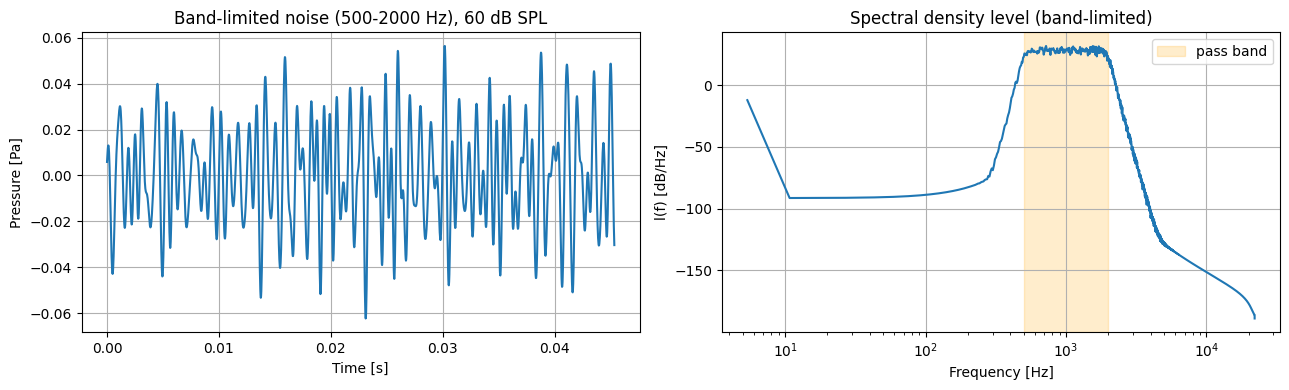

Δf (pass band)                     : 1500.0 Hz
Mean in-band spectral density level: 27.77 dB/Hz
Predicted L = l + 10·log10(Δf/Hz)  : 59.54 dB
Measured L (from RMS)              : 60.00 dB   (should be ≈ 60.0 dB, what we asked for)


In [5]:

def bandpass_filter(x, fs, f_lo, f_hi, order=8):
    '''Zero-phase Butterworth bandpass filter.'''
    sos = sig.butter(order, [f_lo, f_hi], btype='bandpass', fs=fs, output='sos')
    return sig.sosfiltfilt(sos, x)

# --- Demo: band-limit to 500-2000 Hz, and set that band to 60 dB SPL ---
f_lo, f_hi = 500.0, 2000.0
t2, x_full = generate_white_noise(fs, duration, target_spl, seed=7)
x_band = bandpass_filter(x_full, fs, f_lo, f_hi)

# Rescale so the *filtered* signal itself sits at the target SPL
rms_band = np.sqrt(np.mean(x_band**2))
x_band = x_band / rms_band * spl_to_rms(target_spl)

f2, Pxx2 = compute_psd(x_band, fs, nperseg=8192)
l_f2 = psd_to_density_level(Pxx2)

in_band = (f2 >= f_lo) & (f2 <= f_hi)
l_band = np.mean(l_f2[in_band])
delta_f_band = f_hi - f_lo
L_pred_band = l_band + 10 * np.log10(delta_f_band)
L_meas_band = rms_to_spl(np.sqrt(np.mean(x_band**2)))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(t2[:2000], x_band[:2000])
axes[0].set_title(f"Band-limited noise ({f_lo:.0f}-{f_hi:.0f} Hz), {target_spl:.0f} dB SPL")
axes[0].set_xlabel("Time [s]"); axes[0].set_ylabel("Pressure [Pa]")

axes[1].semilogx(f2[1:], l_f2[1:])
axes[1].axvspan(f_lo, f_hi, color='orange', alpha=0.2, label='pass band')
axes[1].legend()
axes[1].set_xlabel("Frequency [Hz]"); axes[1].set_ylabel("l(f) [dB/Hz]")
axes[1].set_title("Spectral density level (band-limited)")
plt.tight_layout()
plt.show()

print(f"Δf (pass band)                     : {delta_f_band:.1f} Hz")
print(f"Mean in-band spectral density level: {l_band:.2f} dB/Hz")
print(f"Predicted L = l + 10·log10(Δf/Hz)  : {L_pred_band:.2f} dB")
print(f"Measured L (from RMS)              : {L_meas_band:.2f} dB   (should be ≈ {target_spl:.1f} dB, what we asked for)")



## Part 5 — Interactive explorer

Now put it all together. Use the sliders to:

- Set the **target dB SPL** (the level within whichever band is active).
- Toggle **bandpass filtering** on/off.
- When it's on, drag $f_{lo}$ and $f_{hi}$ to change the bandwidth $\Delta f$.

Watch how the **spectral density level $l$** and the reported **$L = l + 10\log_{10}(\Delta f/\mathrm{Hz})$**
track the number you actually set, and how narrowing the band (smaller $\Delta f$) forces
the spectral density level $l$ *up* to keep the same total SPL — the classic
"same loudness, narrower band ⇒ louder per Hz" trade-off.


In [ ]:

FS = 44100
DURATION = 1.0

def update(spl_db=60.0, use_bandpass=False, f_lo=200.0, f_hi=2000.0):
    t, x = generate_white_noise(FS, DURATION, spl_db, seed=1)

    if use_bandpass:
        lo, hi = (f_lo, f_hi) if f_lo < f_hi else (f_hi, f_lo)
        if hi - lo < 10:
            hi = lo + 10
        x = bandpass_filter(x, FS, lo, hi)
        rms = np.sqrt(np.mean(x**2))
        if rms > 0:
            x = x / rms * spl_to_rms(spl_db)
        delta_f = hi - lo
        band_label = f"{lo:.0f}\u2013{hi:.0f} Hz"
    else:
        lo, hi = None, None
        delta_f = FS / 2.0
        band_label = f"0\u2013{FS/2:.0f} Hz (full band)"

    f, Pxx = compute_psd(x, FS, nperseg=8192)
    l_f = psd_to_density_level(Pxx)

    mask = (f >= lo) & (f <= hi) if use_bandpass else (f >= f[1])
    l0 = np.mean(l_f[mask])
    L_pred = l0 + 10 * np.log10(delta_f)
    L_meas = rms_to_spl(np.sqrt(np.mean(x**2)))

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(t[:2000], x[:2000])
    axes[0].set_title("Time domain (zoom)")
    axes[0].set_xlabel("Time [s]"); axes[0].set_ylabel("Pressure [Pa]")

    axes[1].semilogx(f[1:], l_f[1:])
    if use_bandpass:
        axes[1].axvspan(lo, hi, color='orange', alpha=0.2, label='pass band')
        axes[1].legend()
    axes[1].set_xlabel("Frequency [Hz]"); axes[1].set_ylabel("l(f) [dB/Hz]")
    axes[1].set_title("Spectral density level")
    plt.tight_layout()
    plt.show()

    display(Markdown(
        f"**Band:** {band_label}  \n"
        f"**\u0394f** = {delta_f:.1f} Hz  \n"
        f"**Mean spectral density level, l** \u2248 {l0:.2f} dB/Hz  \n"
        f"**Predicted band level**  L = l + 10\u00b7log10(\u0394f/Hz) = {L_pred:.2f} dB  \n"
        f"**Measured band level** (from RMS) = {L_meas:.2f} dB  \n"
        f"**Target SPL you set** = {spl_db:.1f} dB"
    ))

spl_slider = FloatSlider(value=60, min=20, max=100, step=1, description='SPL [dB]', continuous_update=False)
bp_checkbox = Checkbox(value=False, description='Bandpass filter')
flo_slider = FloatLogSlider(value=200, base=10, min=1, max=4.3, step=0.01, description='f_lo [Hz]', continuous_update=False)
fhi_slider = FloatLogSlider(value=2000, base=10, min=1, max=4.3, step=0.01, description='f_hi [Hz]', continuous_update=False)

ui = VBox([spl_slider, bp_checkbox, HBox([flo_slider, fhi_slider])])
out = interactive_output(update, {
    'spl_db': spl_slider, 'use_bandpass': bp_checkbox,
    'f_lo': flo_slider, 'f_hi': fhi_slider
})

display(ui, out)


Output()


## Summary

| Quantity | Symbol | Units | What it tells you |
|---|---|---|---|
| Sound pressure level | $L_p$ | dB (re 20 µPa) | Overall loudness, from time-domain RMS |
| Spectral (density) level | $l(f)$ | dB per Hz | Loudness "density" — how energy is spread over frequency |
| Band level | $L$ | dB (re 20 µPa) | Loudness within a chosen bandwidth $\Delta f$ |

**Key relationship** (for a spectrum that's flat within the band of interest):

$$
L = l + 10\log_{10}\!\left(\frac{\Delta f}{\mathrm{Hz}}\right)
$$

**Things to try next:**
- Set a very narrow band (small $\Delta f$) at a fixed SPL — watch $l$ rise sharply.
- Compare two bands of equal $\Delta f$ but placed at different center frequencies — for
  true white noise, $l$ should stay the same either way.
- Replace the Gaussian white-noise generator with **pink noise** (PSD $\propto 1/f$) and
  see how $l(f)$ is no longer flat, so the simple formula above only holds approximately,
  band by band.
